<a href="https://colab.research.google.com/github/evelyn450511/ModelosEstocasticos-EDTS-/blob/main/Matriz_Fuundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matriz Fundamental
*Evelyn Daniela Tapia Serrano*


 **1.Serpientes y escaleras**

*¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero?*

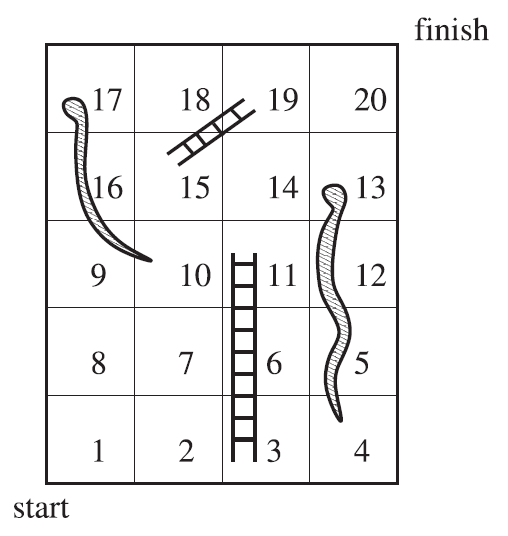

El objetivo es encontrar el número esperado de movimientos para llegar al estado final.

**modelo matemático:**

Sea $S=\{1,2,3,...,20\}$ el conjunto de estados. Definimos:

$E_i$: número esperado de tiradas para llegar a la casilla 20 partiendo de la casilla $i$

Considerando un dado de 6 caras, la ecuación de recurrencia para un estado $i$ es:

$E_i = 1 + \sum_{k=1}^{6} \frac{1}{6}E_{next(i+k)}
$

Donde:

$next(j)$ es la posición final

Note que:


*   Escaleras: $3⟶11,15⟶19$
*   Serpientes: $17⟶9,13⟶5$ (*saltos*)
* Fin: si $j\geq 20$,$E_j=0$
*   Estados: 1 al 19 (*transitorios*), 20 (*absorbente*)



In [2]:
import numpy as np
import sympy as sp


**solución analítica**

In [3]:
def solve_snakes_analytical():
    # Definimos variables para los estados 1 al 19
    E = sp.symbols(f'E1:{20}')
    eqs = []

    # Mapeo de saltos
    jump = {3: 11, 15: 19, 17: 9, 13: 5}

    for i in range(1, 20):
        # Calculamos el valor esperado para el estado actual
        expected_val = 1
        for die in range(1, 7):
            pos = i + die
            if pos >= 20:
                expected_val += 1/6 * 0
            else:
                final_pos = jump.get(pos, pos)
                expected_val += 1/6 * E[final_pos - 1]

        eqs.append(sp.Eq(E[i-1], expected_val))

    sol = sp.solve(eqs, E)
    return sol[E[0]]

**Simulación**

In [4]:
def simulate_snakes(n_sims=100000):
    jumps = {3: 11, 15: 19, 17: 9, 13: 5}
    total_turns = 0
    for _ in range(n_sims):
        pos = 1
        turns = 0
        while pos < 20:
            pos += np.random.randint(1, 7)
            pos = jumps.get(pos, pos)
            turns += 1
        total_turns += turns
    return total_turns / n_sims

avg_analytical = solve_snakes_analytical()
avg_sim = simulate_snakes()

**Resultados**

In [5]:
print(f"Promedio Analítico: {float(avg_analytical):.4f}")
print(f"Promedio Simulación: {avg_sim:.4f}")


Promedio Analítico: 6.8806
Promedio Simulación: 6.8823


**2.Ratón:**

*¿Cuál es la probabilidad de que un ratón, iniciando  en la casilla 0, alcance la comida?*

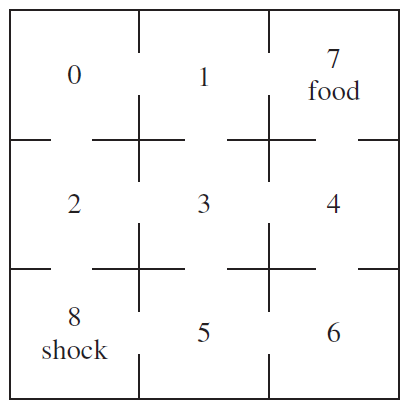

El ratón se mueve aleatoriamente entre casillas adyacentes.



*  Estados de Absorción: 7 (*Comida*) y 8 (*Shock*).

*   Estados Transitorios: $\{0, 1, 2, 3, 4, 5, 6\}$


**modelo matemático**

Sea $P$ la matriz de transición. la dividimos en su forma canónica:

$P=  \begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}$

Donde:

*   $Q$ son las transiciones entre estados transitorios
*   $R$ son las transiciones de estados transitorios e absorbentes

La probabilidad de ser absorbido por el estado 7 partiendo de 0 es: $B =(I-Q)^{-1}R$



**Definición de Probabilidades:**

El ratón se mueve con probabilidad uniforme hacia sus vecinos disponibles:

* Estado 0: 2 salidas (1,2) →P=$\frac{1}{2}$

* Estado 1: 3 salidas (0,3,7) →P=$\frac{1}{3}$

* Estado 2: 3 salidas (0,3,8) →P=$\frac{1}{3}$

* Estado 3: 4 salidas (1,2,4,5) →P=$\frac{1}{4}$

* Estado 4: 3 salidas (3,6,7) →P=$\frac{1}{3}$

* Estado 5: 3 salidas (3,6,8) →P=$\frac{1}{3}$

* Estado 6: 2 salidas (4,5) →P=$\frac{1}{2}$

**matriz de Transición**

$P=\begin{pmatrix}
0 & 1/2 & 1/2 & 0 & 0 & 0 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 & 1/3 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 & 0 & 1/3 \\
0 & 1/4 & 1/4 & 0 & 1/4 & 1/4 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 & 1/3 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 & 0 & 1/3 \\
0 & 0 & 0 & 0 & 1/2 & 1/2 & 0 & 0 & 0 \\
\hline
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}$

**submatriz $Q$:**

$$Q = \begin{pmatrix}
0 & 1/2 & 1/2 & 0 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 \\
0 & 1/4 & 1/4 & 0 & 1/4 & 1/4 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 \\
0 & 0 & 0 & 0 & 1/2 & 1/2 & 0
\end{pmatrix}$$

**submatriz $R$:**
$$R = \begin{pmatrix}
0 & 0 \\
1/3 & 0 \\
0 & 1/3 \\
0 & 0 \\
1/3 & 0 \\
0 & 1/3 \\
0 & 0
\end{pmatrix}$$

**Proceso analitico**

In [13]:


def prob_ra():
    # 1. Definir la submatriz Q (Transiciones entre estados transitorios 0-6)
    Q = sp.Matrix([
        [0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0, 0],
        [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0],
        [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0],
        [0, sp.Rational(1,4), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,4), 0], # Estado 3
        [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3)],
        [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3)],
        [0, 0, 0, 0, sp.Rational(1,2), sp.Rational(1,2), 0]
    ])


    R = sp.Matrix([
        [0, 0],
        [sp.Rational(1,3), 0],
        [0, sp.Rational(1,3)],
        [0, 0],
        [sp.Rational(1,3), 0],
        [0, sp.Rational(1,3)],
        [0, 0]
    ])


    I = sp.eye(Q.shape[0])
    N = (I - Q).inv()


    B = N * R

    return B


**Simulación**

In [8]:
def simular_raton(n_sim=100000):
    adj = {0:[1,2],
           1:[0,3,7],
           2:[0,3,8],
           3:[1,2,4,5],
           4:[3,6,7],
           5:[3,6,8],
           6:[4,5]}
    exitos = 0
    for _ in range(n_sim):
        pos = 0
        while pos < 7:
            pos = np.random.choice(adj[pos])
        if pos == 7: exitos += 1
    return exitos / n_sim

**Resultados**

In [17]:
B =prob_ra()
prob_desde_0 = B.row(0)[0]

print(f"Promedio analitico: {prob_desde_0}")
print(f"Promedio Simulación: {simular_raton():.4f}")


Promedio analitico: 1/2
Promedio Simulación: 0.5004


**Conclusiones**

1. Serpientes y Escaleras: El tablero es pequeño (20 casillas), por lo que el número promedio de tiradas suele ser bajo (alrededor de 4 a 6 turnos). La escalera 3→11 es crítica, ya que salta casi la mitad del tablero. La simulación debe converger al valor exacto conforme aumentan las iteraciones.

2. El Ratón: Debido a la simetría del laberinto (las rutas hacia la comida y el shock son prácticamente espejos), se espera que la probabilidad sea exactamente 0.5 (50%). El cálculo con la matriz fundamental $(I−Q)^{
−1}$
  confirma si existe algún sesgo estructural en los pasillos que favorezca un estado sobre el otro. En este diseño específico, el camino 0→1→7 y 0→2→8 son equivalentes.